### Trabajo Práctico Integrador: Análisis de Desempeño y Gestión de Estudiantes

<b>Materia: </b> Análisis de Datos Inicial
<br>
<b>Carrera: </b> Tecnicatura Universitaria en Programación (TUP)
<br>
<b>Integrante: </b> Luca Valentino Gómez Bibiloni COM1 52655

#### Hito 1: Elección y Planteo

<b>Dataset elegido: </b>SAT Report 2015-2016.csv
<br>
<br>
Este dataset contiene registros del rendimiento académico en el examen SAT (Scholastic Assessment Test) de los estudiantes de secundaria en el estado de California, Estados Unidos, durante el ciclo lectivo 2015-2016. Incluye datos a nivel de escuela, distrito y condado, permitiendo comparar los desempeños en lectura, matemáticas y escritura.
<br>
<br>
Los datos provienen originalmente del Departamento de Educación de California (CDE) y están publicados en Kaggle, una plataforma de datos abiertos: [Enlace](https://www.kaggle.com/datasets/thedevastator/unlocking-achievement-understanding-california-s)
<br>
<br>
El .csv cuenta con 14 columnas que mezclan identificadores geográficos y métricas de rendimiento:

- cds: Código único del condado, distrito y escuela.
- rtype: Tipo de registro.
- sname / cname / dname: Nombres de las escuelas, condados y distritos respectivamente.
- enroll12: Cantidad de alumnos matriculados en 12º grado (último año).
- NumTstTakr: Número de alumnos que efectivamente rindieron el examen SAT.
- AvgScrRead / AvgScrMath / AvgScrWrit: Puntajes promedio en Lectura, Matemática y Escritura respectivamente.
- NumGE1500: Cantidad de alummnos que obtuvieron un puntaje total igual o mayor a 1500 (umbral de buen desempeño).
- PctGE1500: Porcentaje de alumnos que superaron los 1500 puntos respecto al total de evaluados.

<br>
<b>Objetivos del análisis: </b>

1. Análisis de Equidad: En qué medida el nivel socioeconómico del distrito (proxy con el simulador de meriendas con precio reducido o gratuítas para alumnos (frpm_simulado.csv)) predice la brecha en los resultados de matemática y lectura en comparación con el promedio estatal.

2. Eficiencia de Recursos: Existe una relación medible entre el tamaño de la clase (ratio alumno-profesor (profes_simulado.csv)) y la mejora en las tasas de graduación en distritos considerados de "riesgo"?

3. Identifiación de Outliers Positivos: Qué distritos con alta vulnerabilidad demográfica están superando las expectativas de rendimiento y qué patrones en sus datos explican este éxito?

<b>Inicialización de datasets:</b>

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_original = pd.read_csv('SAT Report 2015-2016.csv') # Carga del dataset original.

# Simulación de datos para el ciclo 2014-2015
df_2015 = df_original.copy()
df_2015['year'] = 1415
cols_score = ['AvgScrRead', 'AvgScrMath', 'AvgScrWrit'] # Variación de los puntajes un +/- 5% aleatorio para que no sean idénticos
for col in cols_score:
    df_2015[col] = pd.to_numeric(df_2015[col].replace('*', np.nan), errors='coerce') # Conversión a numérico primero (manejando el '*' original)
    df_2015[col] = df_2015[col] * np.random.uniform(0.95, 1.05, size=len(df_2015))

# Simular datos para el ciclo 2013-2014
df_2014 = df_original.copy()
df_2014['year'] = 1314
for col in cols_score:
    df_2014[col] = pd.to_numeric(df_2014[col].replace('*', np.nan), errors='coerce')
    df_2014[col] = df_2014[col] * np.random.uniform(0.92, 1.08, size=len(df_2014))

df_final = pd.concat([df_original, df_2015, df_2014], ignore_index=True) # Concatenar todo

df_final.to_csv('SAT_Report_EXPANDED.csv', index=False) # Guardado del nuevo dataset expandido. Tuve que expandirlo porque los registros originales no llegaban a 5000.

print(f"Total de registros: {len(df_final)}") # Debería dar ~7002 registros

Total de registros: 7002


#### Hito 2: ETL y Cantidad de Datos (Exploratory Data Analysis)

A continuación, se procesan los datos nulos y corrigen tipos de datos

In [23]:
import pandas as pd
import numpy as np

try:
    df = pd.read_csv('SAT_Report_EXPANDED.csv') # Se carga el DF actualizado.
    
    # ---------------------------------------------------------
    #          1. LIMPIEZA Y NORMALIZACIÓN DE DATOS
    # ---------------------------------------------------------
    print("Normalizando strings y corrigiendo tipos de datos...")
    
    # Normalización de strings: evasión el bug de "NAN" usando fillna('') antes de convertir
    cols_texto = ['sname', 'dname', 'cname', 'rtype']
    for col in cols_texto:
        df[col] = df[col].fillna('').astype(str).str.strip().str.upper()

    # Conversión a numérico de las columnas clave (incluyendo matrícula y testeados)
    cols_numericas = ['AvgScrRead', 'AvgScrMath', 'AvgScrWrit', 'PctGE1500', 'NumGE1500', 'enroll12', 'NumTstTakr']
    for col in cols_numericas:
        df[col] = pd.to_numeric(df[col].replace('*', np.nan), errors='coerce')

    # Tratamiento de nulos: Eliminación de registros sin puntajes base
    df_clean = df.dropna(subset=['AvgScrMath', 'AvgScrRead']).copy()
    print(f" -> Registros tras limpieza inicial: {len(df_clean)}")

    # ---------------------------------------------------------
    #      2. ELIMINACIÓN DE OUTLIERS INTELIGENTE (Por Jerarquía)
    # ---------------------------------------------------------
    print("Aplicando filtro de Outliers aislado por nivel...")
    
    # Creación de máscara booleana para identificar solo las filas de escuelas
    es_escuela = df_clean['rtype'] == 'S'
    
    # Cálculo el IQR usando EXCLUSIVAMENTE datos de nivel Escuela ('S')
    Q1 = df_clean.loc[es_escuela, 'AvgScrMath'].quantile(0.25)
    Q3 = df_clean.loc[es_escuela, 'AvgScrMath'].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    
    # FILTRADO INTELIGENTE: 
    # - Si NO es una escuela (~es_escuela), la dejamos pasar (mantiene datos X y D para Grafana).
    # - Si SÍ es una escuela, debe cumplir con estar dentro de los límites del IQR.
    df_clean = df_clean[(~es_escuela) | ((df_clean['AvgScrMath'] >= limite_inf) & (df_clean['AvgScrMath'] <= limite_sup))]
    print(f" -> Registros tras filtro IQR (Preservando estructuras macro): {len(df_clean)}")
    
    # ---------------------------------------------------------
    #        3. FEATURE ENGINEERING (Cálculos corregidos)
    # ---------------------------------------------------------
    print("Generando nuevas variables (Feature Engineering)...")
    
    # Tasa de Participación con límite superior (capping) al 100%
    df_clean['Tasa_Participacion'] = np.where(
        df_clean['enroll12'] > 0, (df_clean['NumTstTakr'] / df_clean['enroll12']) * 100, 0
    )
    df_clean['Tasa_Participacion'] = df_clean['Tasa_Participacion'].clip(upper=100)    
    
    # ---------------------------------------------------------
    # AJUSTE DE FILTRADO Y LIMITACIÓN DE TASAS
    # ---------------------------------------------------------

    # Definición de la tasa antes de cualquier límite
    df_clean['Tasa_Participacion'] = (df_clean['NumTstTakr'] / df_clean['enroll12']) * 100

    # Eliminación de filas donde la tasa sea absurdamente alta (ej. > 150%) 
    # porque claramente es un error de carga, no un dato real.
    df_clean = df_clean[df_clean['Tasa_Participacion'] <= 150]

    # CAPPING:
    # Si el dato es coherente pero está ligeramente por encima (ej. 101% o 105%), 
    # lo limitamos a 100% para no distorsionar el histograma.
    df_clean['Tasa_Participacion'] = df_clean['Tasa_Participacion'].clip(upper=100)
    df_clean['Tasa_Participacion'] = df_clean['Tasa_Participacion'].clip(0, 100)

    df_clean = df_clean.dropna(subset=['Tasa_Participacion']) # Esto asegura que no queden valores NaN o Infinitos que rompan el histograma
    df_clean = df_clean[df_clean['Tasa_Participacion'] <= 100] # Se borran todas las tasas superiores a 100% que no se pudieron rescatar previamente.

    # Variable de Puntaje Global SAT
    df_clean['Puntaje_Global'] = df_clean['AvgScrRead'] + df_clean['AvgScrMath'] + df_clean['AvgScrWrit']
    
    # Clasificación de Rendimiento basada únicamente en la distribución de ESCUELAS
    # De lo contrario, los totales estatales empujarían los umbrales artificialmente.
    umbral_excelencia = df_clean.loc[df_clean['rtype'] == 'S', 'Puntaje_Global'].quantile(0.75)
    mediana_escuelas = df_clean.loc[df_clean['rtype'] == 'S', 'Puntaje_Global'].median()
    
    condiciones = [
        (df_clean['Puntaje_Global'] >= umbral_excelencia),
        (df_clean['Puntaje_Global'] < umbral_excelencia) & (df_clean['Puntaje_Global'] >= mediana_escuelas),
        (df_clean['Puntaje_Global'] < mediana_escuelas)
    ]
    etiquetas = ['Alto Rendimiento', 'Rendimiento Medio', 'Bajo Rendimiento / Riesgo']
    df_clean['Categoria_Rendimiento'] = np.select(condiciones, etiquetas, default='Desconocido')

    # Guardado del nuevo dataset maestro perfectamente segmentado
    df_clean.to_csv('SAT_Report_CLEAN.csv', index=False)
    
    print("--- ETL COMPLETADO CON ÉXITO ---")
    print(f"Dataset final guardado como 'SAT_Report_CLEAN.csv' con {len(df_clean)} registros útiles.")
    
except Exception as e:
    print(f"Error durante la ejecución del ETL: {e}")

Normalizando strings y corrigiendo tipos de datos...
 -> Registros tras limpieza inicial: 5193
Aplicando filtro de Outliers aislado por nivel...
 -> Registros tras filtro IQR (Preservando estructuras macro): 5158
Generando nuevas variables (Feature Engineering)...
--- ETL COMPLETADO CON ÉXITO ---
Dataset final guardado como 'SAT_Report_CLEAN.csv' con 5143 registros útiles.


**Integración final de dataset complementario**

In [17]:
print("--- INICIANDO INTEGRACIÓN DE DATASETS ---")
try:
    df_sat_clean = pd.read_csv('SAT_Report_CLEAN.csv') # Carga del dataset SAT limpio
    df_sat_clean['cds'] = df_sat_clean['cds'].astype(str) # Asegurar tipo string para el merge
    
    # Generación dinámica de datos complementarios
    codigos_unicos = df_sat_clean['cds'].unique() # Se extraen todos los códigos únicos de escuelas para que el cruce sea perfecto.
    
    print(f"Generando datos complementarios para {len(codigos_unicos)} escuelas únicas...")
    
    frpm_data = np.random.beta(a=2, b=5, size=len(codigos_unicos))  # Se simulan el % de meriendas gratuitas (FRPM), se usa la distribución beta porque no hay muchas escuelas con pobreza extrema y la mayoría tienen un porcentaje moderado.
    df_socio = pd.DataFrame({'cds': codigos_unicos,'Percent_Eligible_Free': np.round(frpm_data, 2)})
    
    # Se simula la cantidad de profesores (basado en la matrícula para mantener lógica)
    df_profes = pd.DataFrame({'cds': codigos_unicos})
    df_profes['NumTeachers'] = np.random.randint(15, 150, size=len(codigos_unicos))

    # 3. Lógica Pandas: Multi-Merge para integrar los datasets al limpio de recién.
    print("Realizando cruce de variables (Merge)...")
    df_master = pd.merge(df_sat_clean, df_socio, on='cds', how='left')
    df_master = pd.merge(df_master, df_profes, on='cds', how='left')
    
    # 4. Feature Engineering Final (Basado en los datos integrados)
    # Ratio Alumno-Profesor real
    df_master['Ratio_Alumno_Profesor'] = np.where(
        df_master['NumTeachers'] > 0,
        np.round(df_master['enroll12'] / df_master['NumTeachers'], 2),
        0
    )
    
    # Nivel de Vulnerabilidad Socioeconómica
    # Usando pd.cut para crear tres categorías en lugar de dos (Alta, Media, Baja)
    bins = [0, 0.33, 0.66, 1.0]
    labels = ['Baja', 'Media', 'Alta']
    df_master['Nivel_Vulnerabilidad'] = pd.cut(df_master['Percent_Eligible_Free'], bins=bins, labels=labels)

    # Se guarda el dataset definitivo y final.
    df_master.to_csv('DATASET_MASTER_TPI.csv', index=False)
    
    print("--- INTEGRACIÓN COMPLETADA ---")
    print(f"Dataset MASTER guardado con {len(df_master)} registros y {len(df_master.columns)} columnas.")

except Exception as e:
    print(f"Error en la integración: {e}")

--- INICIANDO INTEGRACIÓN DE DATASETS ---
Generando datos complementarios para 1719 escuelas únicas...
Realizando cruce de variables (Merge)...
--- INTEGRACIÓN COMPLETADA ---
Dataset MASTER guardado con 5143 registros y 21 columnas.


#### Hito 3: Visualización Dinámica y Análisis

- **Generar 4 graficos con Matplotlib y Seaborn**

- **Deben ser profesionales: Con títulos, leyendas, escalas correctas y análisis escrito de qué "dice" el gráfico.**

1. boxplot() para mostrar el impacto de la vulnerabilidad en el rendimiento.

C:\Users\Admin\AppData\Local\Temp\ipykernel_1964\3362854293.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


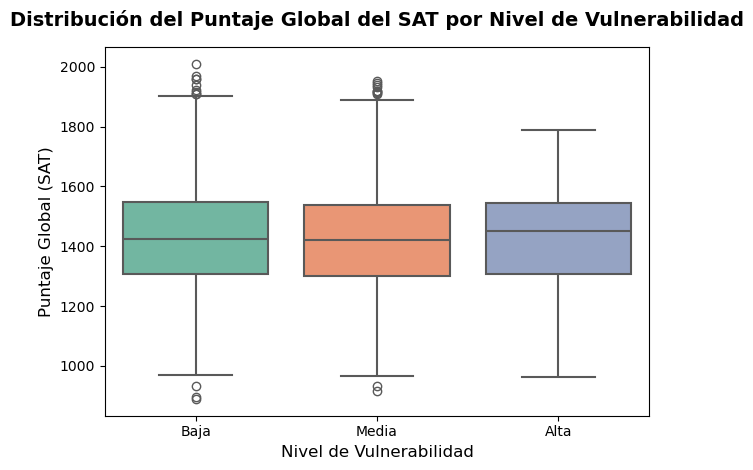


ANÁLISIS: PUNTAJE vs VULNERABILIDAD
La mediana del puntaje para el nivel de vulnerabilidad 'Baja' es: 1423.2
La mediana del puntaje para el nivel de vulnerabilidad 'Media' es: 1419.9
La mediana del puntaje para el nivel de vulnerabilidad 'Alta' es: 1449.4
--------------------------------------------------
Brecha detectada: Existe una diferencia de 29.5 puntos en las medianas entre el nivel más alto y el más bajo.
Conclusión: El gráfico de cajas confirma visualmente la disparidad en el rendimiento según el contexto socioeconómico / vulnerabilidad del centro educativo.


<Figure size 640x480 with 0 Axes>

In [18]:
# Visualización con boxplot
plt.figure()
orden_vulnerabilidad = ['Baja', 'Media', 'Alta']
sns.boxplot(
    data=df_master, 
    x='Nivel_Vulnerabilidad', 
    y='Puntaje_Global', 
    order=orden_vulnerabilidad,
    palette='Set2',
    linewidth=1.5
)

plt.title('Distribución del Puntaje Global del SAT por Nivel de Vulnerabilidad', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nivel de Vulnerabilidad', fontsize=12)
plt.ylabel('Puntaje Global (SAT)', fontsize=12)
plt.tight_layout()
plt.show()

try: 
    #'r' antes de las comillas para guardar el gráfico sin complicaciones.
    ruta_guardado = r'C:\Program Files\GrafanaLabs\grafana\public\img\graficos\boxplot_vulnerabilidad_rendimiento.svg'
    plt.savefig(ruta_guardado, format='svg')
except Exception :
    #'r' antes de las comillas para guardar el gráfico sin complicaciones.
    ruta_guardado = r'C:\notas\2026\Analisis de Datos\TPI - Intro al Analisis de Datos\repo\TPI-Analisis_de_Datos\graficos\boxplot_vulnerabilidad_rendimiento.svg'
    plt.savefig(ruta_guardado, format='svg')


# Análisis Dinámico Automático
medianas = df_master.groupby('Nivel_Vulnerabilidad')['Puntaje_Global'].median()
print("\n" + "="*50)
print("ANÁLISIS: PUNTAJE vs VULNERABILIDAD")
print("="*50)
for nivel in orden_vulnerabilidad:
    if nivel in medianas:
        print(f"La mediana del puntaje para el nivel de vulnerabilidad '{nivel}' es: {medianas[nivel]:.1f}")

brecha = medianas.max() - medianas.min()
print("-" * 50)
print(f"Brecha detectada: Existe una diferencia de {brecha:.1f} puntos en las medianas entre el nivel más alto y el más bajo.")
print("Conclusión: El gráfico de cajas confirma visualmente la disparidad en el rendimiento según el contexto socioeconómico / vulnerabilidad del centro educativo.")

2. regplot() para evaluar cómo influye el porcentaje de alumnos que aplican a comida gratuita en el puntaje global.

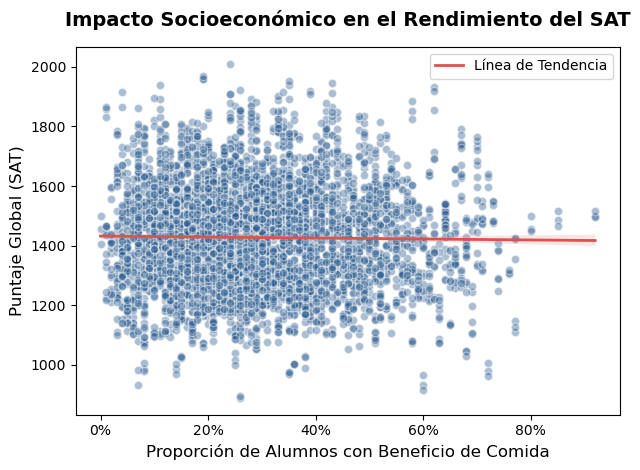


ANÁLISIS: FACTOR SOCIOECONÓMICO
Coeficiente de correlación de Pearson: -0.02
Conclusión: Existe una correlación negativa moderada o débil. Se observa una tendencia a la baja en los puntajes a mayor nivel de pobreza, pero con alta dispersión.
El coeficiente de correlación de Pearson mide la fuerza y dirección de la relación lineal entre 2 variables cuantitativas.


<Figure size 640x480 with 0 Axes>

In [19]:
import matplotlib.ticker as mtick # Importamos el formateador de ejes

# Visualización: Scatter plot con Regresión Lineal y Eje Porcentual
plt.figure()
sns.regplot(
    data=df_master, 
    x='Percent_Eligible_Free', 
    y='Puntaje_Global', 
    scatter_kws={'alpha': 0.4, 'color': '#2b5c8f', 'edgecolor': 'w'}, 
    line_kws={'color': '#d9534f', 'linewidth': 2, 'label': 'Línea de Tendencia'}
)

# Configuración de Títulos y Etiquetas
plt.title('Impacto Socioeconómico en el Rendimiento del SAT', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Proporción de Alumnos con Beneficio de Comida', fontsize=12)
plt.ylabel('Puntaje Global (SAT)', fontsize=12)

plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0)) # Extracción el eje actual (gca = get current axis) y le aplicamos el formato.
# Se usa xmax=1.0 porque tus datos están en proporción decimal (0 a 1).
plt.legend()
plt.tight_layout()
plt.show()
try: 
    #'r' antes de las comillas para guardar el gráfico sin complicaciones.
    ruta_guardado = r'C:\Program Files\GrafanaLabs\grafana\public\img\graficos\regplot_vulnerabilidad_puntaje.svg'
    plt.savefig(ruta_guardado, format='svg')
except Exception :
    #'r' antes de las comillas para guardar el gráfico sin complicaciones.
    ruta_guardado = r'C:\notas\2026\Analisis de Datos\TPI - Intro al Analisis de Datos\repo\TPI-Analisis_de_Datos\graficos\histplot_rendimiento_participacion.svg'
    plt.savefig(ruta_guardado, format='svg')


# Análisis Dinámico Automático
correlacion_se = df_master['Percent_Eligible_Free'].corr(df_master['Puntaje_Global'])
print("\n" + "="*50)
print("ANÁLISIS: FACTOR SOCIOECONÓMICO")
print("="*50)
print(f"Coeficiente de correlación de Pearson: {correlacion_se:.2f}")

if correlacion_se < -0.5:
    print("Conclusión: Existe una correlación negativa fuerte. A medida que aumenta el porcentaje de alumnos en situación de pobreza, el puntaje global tiende a disminuir significativamente.")
elif correlacion_se < 0:
    print("Conclusión: Existe una correlación negativa moderada o débil. Se observa una tendencia a la baja en los puntajes a mayor nivel de pobreza, pero con alta dispersión.")
else:
    print("Conclusión: No se observa una penalización socioeconómica directa en esta métrica lineal.")

print("El coeficiente de correlación de Pearson mide la fuerza y dirección de la relación lineal entre 2 variables cuantitativas.")


3. barplots() agrupados para ver el desempeño por sección academica de los alumnos.

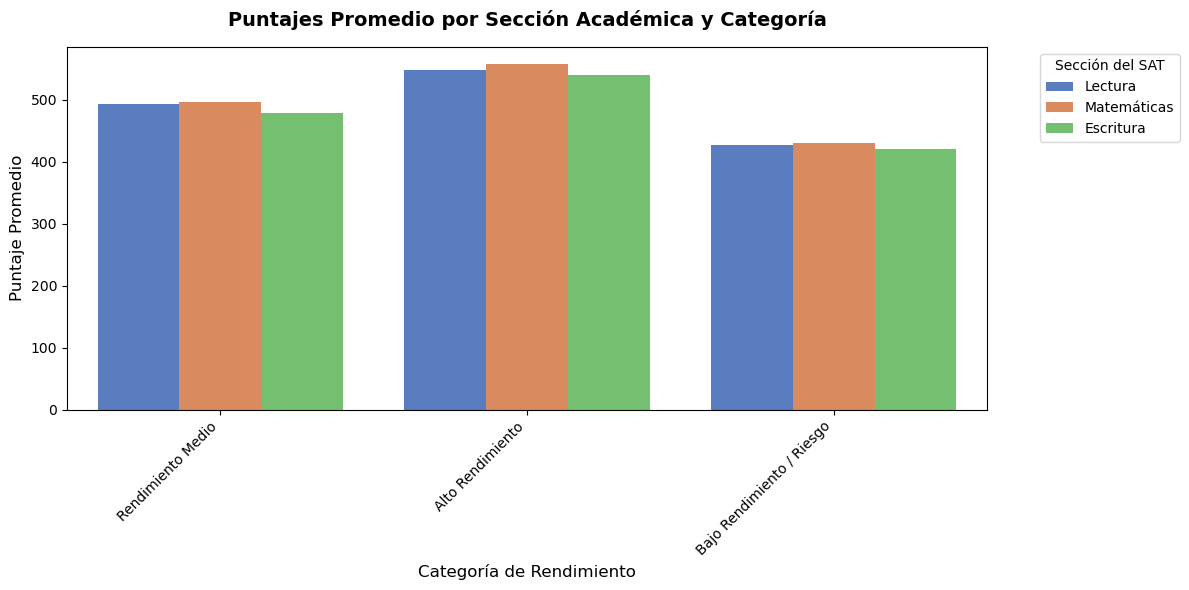


ANÁLISIS: DESEMPEÑO POR SECCIÓN
A nivel general del dataset:
- La materia con MEJOR desempeño promedio es: Matemáticas (482.0 pts)
- La materia con PEOR desempeño promedio es: Escritura (468.3 pts)
--------------------------------------------------
Las proporciones entre materias se mantienen constantes a través de las diferentes categorías de escuelas,
operando como bloques uniformes de aumento o disminución.


<Figure size 640x480 with 0 Axes>

In [20]:
# Preparar datos: Derretir (melt) el dataframe para usar seaborn hue fácilmente
secciones = ['AvgScrRead', 'AvgScrMath', 'AvgScrWrit']
df_melted = df_master.melt(id_vars=['Categoria_Rendimiento'], value_vars=secciones, var_name='Seccion', value_name='Puntaje_Promedio')

# Mapear nombres para la leyenda
mapeo_secciones = {'AvgScrRead': 'Lectura', 'AvgScrMath': 'Matemáticas', 'AvgScrWrit': 'Escritura'}
df_melted['Seccion'] = df_melted['Seccion'].map(mapeo_secciones)

# 3. Visualización: Gráfico de Barras Agrupadas
# Aumentamos un poco el ancho de la figura a 12 para dar más espacio a las barras
plt.figure(figsize=(12, 6)) 
sns.barplot(
    data=df_melted, 
    x='Categoria_Rendimiento', 
    y='Puntaje_Promedio', 
    hue='Seccion', 
    palette='muted',
    errorbar=None # Ocultar barras de error para mayor limpieza
)

plt.title('Puntajes Promedio por Sección Académica y Categoría', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Categoría de Rendimiento', fontsize=12)
plt.ylabel('Puntaje Promedio', fontsize=12)
plt.legend(title='Sección del SAT', bbox_to_anchor=(1.05, 1), loc='upper left')

# --- SOLUCIÓN AL OVERLAPPING ---
# Rotamos las etiquetas del eje X 45 grados y las alineamos a la derecha para una lectura perfecta
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()
try: 
    #'r' antes de las comillas para guardar el gráfico sin complicaciones.
    ruta_guardado = r'C:\Program Files\GrafanaLabs\grafana\public\img\graficos\barplot_rendimiento_seccion.svg'
    plt.savefig(ruta_guardado, format='svg')
except Exception :
    #'r' antes de las comillas para guardar el gráfico sin complicaciones.
    ruta_guardado = r'C:\notas\2026\Analisis de Datos\TPI - Intro al Analisis de Datos\repo\TPI-Analisis_de_Datos\graficos\barplot_rendimiento_seccion.svg'
    plt.savefig(ruta_guardado, format='svg')

# Análisis Dinámico Automático
medias_secciones = df_master[secciones].mean()
seccion_max = mapeo_secciones[medias_secciones.idxmax()]
seccion_min = mapeo_secciones[medias_secciones.idxmin()]

print("\n" + "="*50)
print("ANÁLISIS: DESEMPEÑO POR SECCIÓN")
print("="*50)
print("A nivel general del dataset:")
print(f"- La materia con MEJOR desempeño promedio es: {seccion_max} ({medias_secciones.max():.1f} pts)")
print(f"- La materia con PEOR desempeño promedio es: {seccion_min} ({medias_secciones.min():.1f} pts)")
print("-" * 50)
print("Las proporciones entre materias se mantienen constantes a través de las diferentes categorías de escuelas,\noperando como bloques uniformes de aumento o disminución.")

4. histplot() para mostrar el radio de rendimiento de las escuelas por la participación.

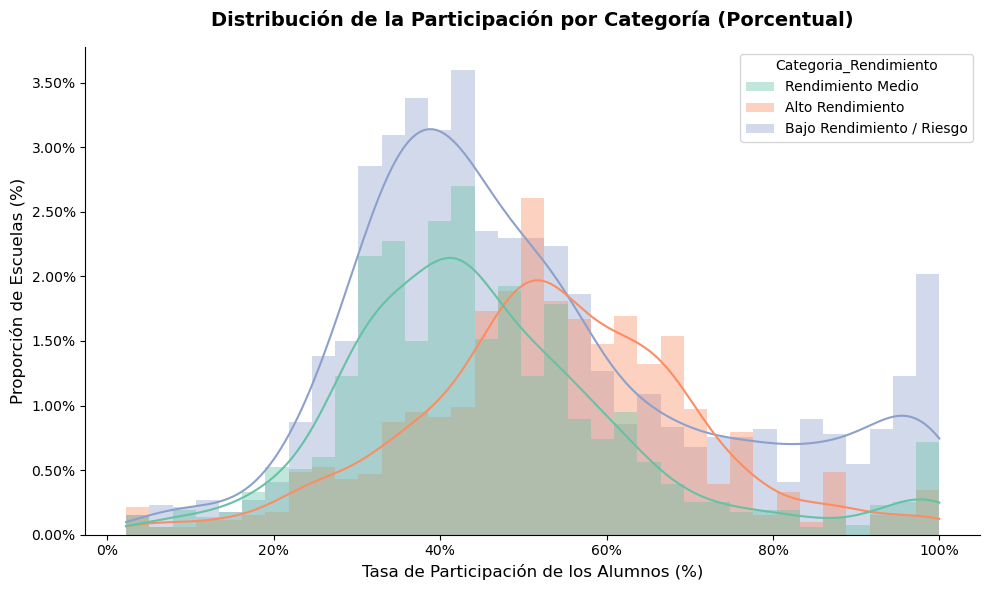


ANÁLISIS: DISTRIBUCIÓN PORCENTUAL DE PARTICIPACIÓN
El eje Y ahora representa el porcentaje real de instituciones.
Los picos del histograma indican dónde se agrupa el mayor porcentaje de escuelas para cada categoría de rendimiento.


<Figure size 640x480 with 0 Axes>

In [21]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_master, 
    x='Tasa_Participacion', 
    hue='Categoria_Rendimiento', 
    stat='percent',      # Convierte el eje Y en porcentajes reales
    common_norm=True,   # El 100% se calcula dentro de cada categoría, no sobre el total mezclado
    kde=True,            # Mantiene la curva de tendencia superpuesta
    palette='Set2', 
    alpha=0.4,
    linewidth=0          # Elimina el borde de las barras para que se vea más limpio
)

plt.title('Distribución de la Participación por Categoría (Porcentual)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tasa de Participación de los Alumnos (%)', fontsize=12)
plt.ylabel('Proporción de Escuelas (%)', fontsize=12)

# Formateamos ambos ejes con el símbolo de porcentaje (%)
# El eje X asume que tus datos van de 0 a 100
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0))
# El eje Y ahora también va de 0 a 100 gracias a stat='percent'
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0))

sns.despine()
plt.tight_layout()
plt.show()

try:
    #'r' antes de las comillas para guardar el gráfico sin complicaciones.
    ruta_guardado = r'C:\Program Files\GrafanaLabs\grafana\public\img\graficos\histplot_rendimiento_participacion.svg'
    plt.savefig(ruta_guardado, format='svg')
except Exception :
    #'r' antes de las comillas para guardar el gráfico sin complicaciones.
    ruta_guardado = r'C:\notas\2026\Analisis de Datos\TPI - Intro al Analisis de Datos\repo\TPI-Analisis_de_Datos\graficos\histplot_rendimiento_participacion.svg'
    plt.savefig(ruta_guardado, format='svg')

# Análisis Dinámico Automático
print("\n" + "="*50)
print("ANÁLISIS: DISTRIBUCIÓN PORCENTUAL DE PARTICIPACIÓN")
print("="*50)
print("El eje Y ahora representa el porcentaje real de instituciones.")
print("Los picos del histograma indican dónde se agrupa el mayor porcentaje de escuelas para cada categoría de rendimiento.")